# Spam And Ham Classification
## Naive Bayes Model


### 1 Problem statement
Given a dataset of emails, determine whether each email is "spam" or "not spam."
This is a binary classification problem, where:
  Input: Email text
  Output: Spam (1) or Ham (0)

### 2 Data collection
Dataset Source - https://www.kaggle.com/datasets/zubairmustafa/spam-and-ham-classification-balanced-dataset/data from Kaggle
It contains: 
  text: the content of the email
  label: indicates whether the email is spam or ham

#### 2.1 Import data and Required Packages

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [11]:
df = pd.read_csv("spam_and_ham_classification.csv")

In [ ]:
df.head()

In [12]:
df.shape

(9989, 2)

### 3. Data checks to perform
Before training the model, several checks are performed:
Check for missing value
Check duplicate entries
Verify data types
Check class dítribution (spam vs ham)

In [13]:
df.isnull().sum()

label    0
text     0
dtype: int64

There are no missing value in the dataset

In [14]:
df.duplicated().sum()

np.int64(0)

There are no duplicate rows in the dataset

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9989 entries, 0 to 9988
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   9989 non-null   object
 1   text    9989 non-null   object
dtypes: object(2)
memory usage: 156.2+ KB


In [16]:
df.describe()

,label,text
count,9989,9989
unique,2,9989
top,ham,into the kingdom of god and those that are ent...
freq,5294,1


Only spam and ham
The class that appears most often is ham
The amount of ham is greater than spam

In [17]:
df['label'].value_counts()

label
ham     5294
spam    4695
Name: count, dtype: int64

The dataset is quite balanced
   ham 53%
   spam 47%
   -> no problem imbalanced data

### 4. Feature engineering

In [18]:
# Text length
df["text_length"] = df['text'].apply(len)

# Number of words
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Number of special characters (! ? $)
df['special_char_count'] = df['text'].apply(lambda x: sum(1 for c in x if not c.isalnum()))

# Number of uppercase letters
df['uppercase_count'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()))

# Keyword features
spam_keys = ['free', 'thats', 'money', 'offer', 'click']

for key in spam_keys:
    df[f'{key}'] = df['text'].apply(lambda x: x.lower().count(key))

### 5. Visualization

#### 5.1 Distribution of Spam with Ham

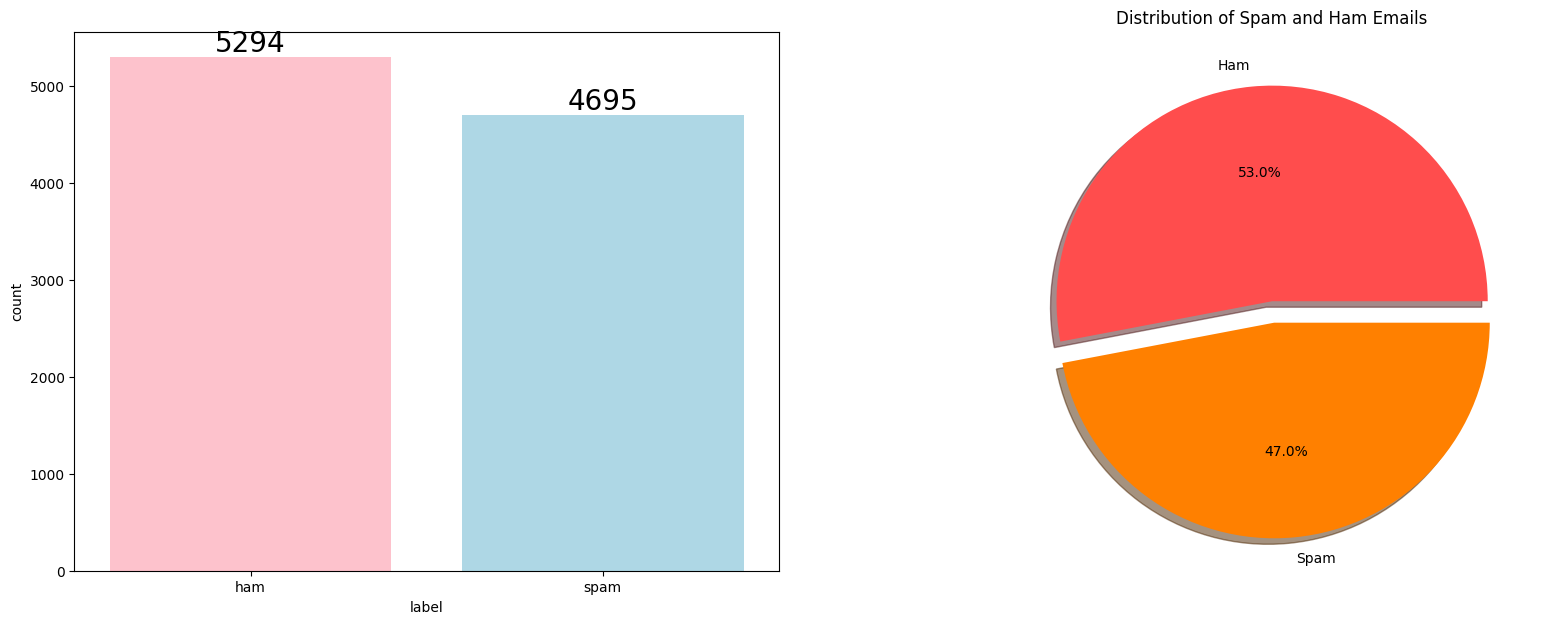

In [19]:
f, ax = plt.subplots(1,2, figsize=(20,7))
color = ["pink", "lightblue"]
sns.countplot(x='label', data=df, palette = color, ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)
plt.pie(x = df['label'].value_counts(), labels=['Ham', 'Spam'], explode=[0, 0.1], autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'] )
plt.title("Distribution of Spam and Ham Emails")
plt.show()

Quantity of ham ≈ spam
Balanced data set → model learns well, no bias

#### 5.3 Text length (spam vs ham)

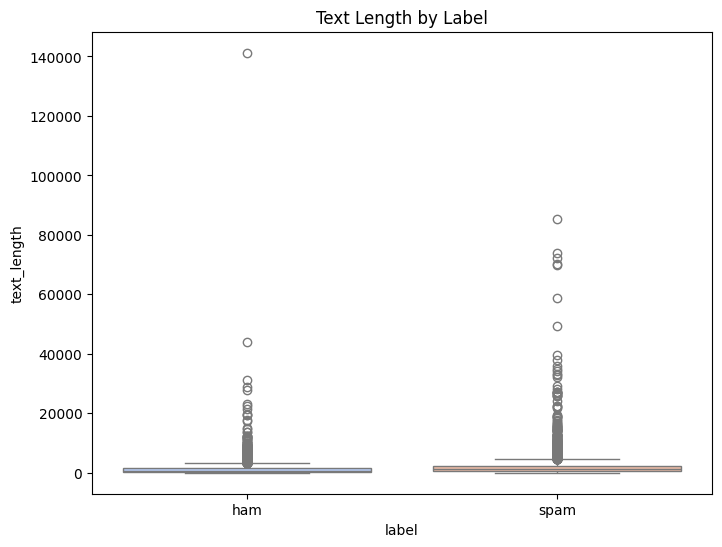

In [20]:
plt.figure(figsize=(8,6))
sns.boxplot(x='label', y='text_length', data=df, palette='coolwarm')
plt.title("Text Length by Label")
plt.show()

Spam often tends to: longer or more special characters
Ham is often more natural

#### 5.4 Word Count Distribution

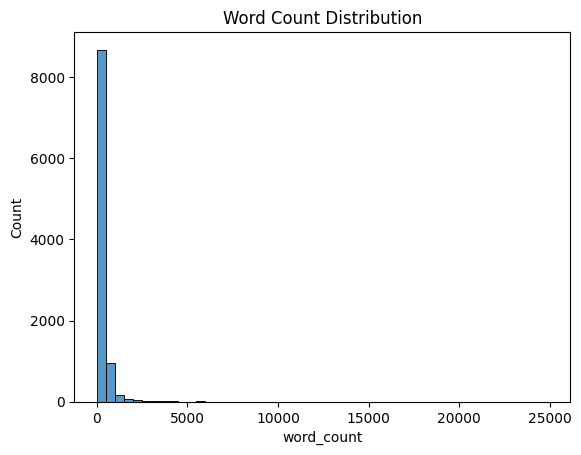

In [21]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

#### 5.5 Top words

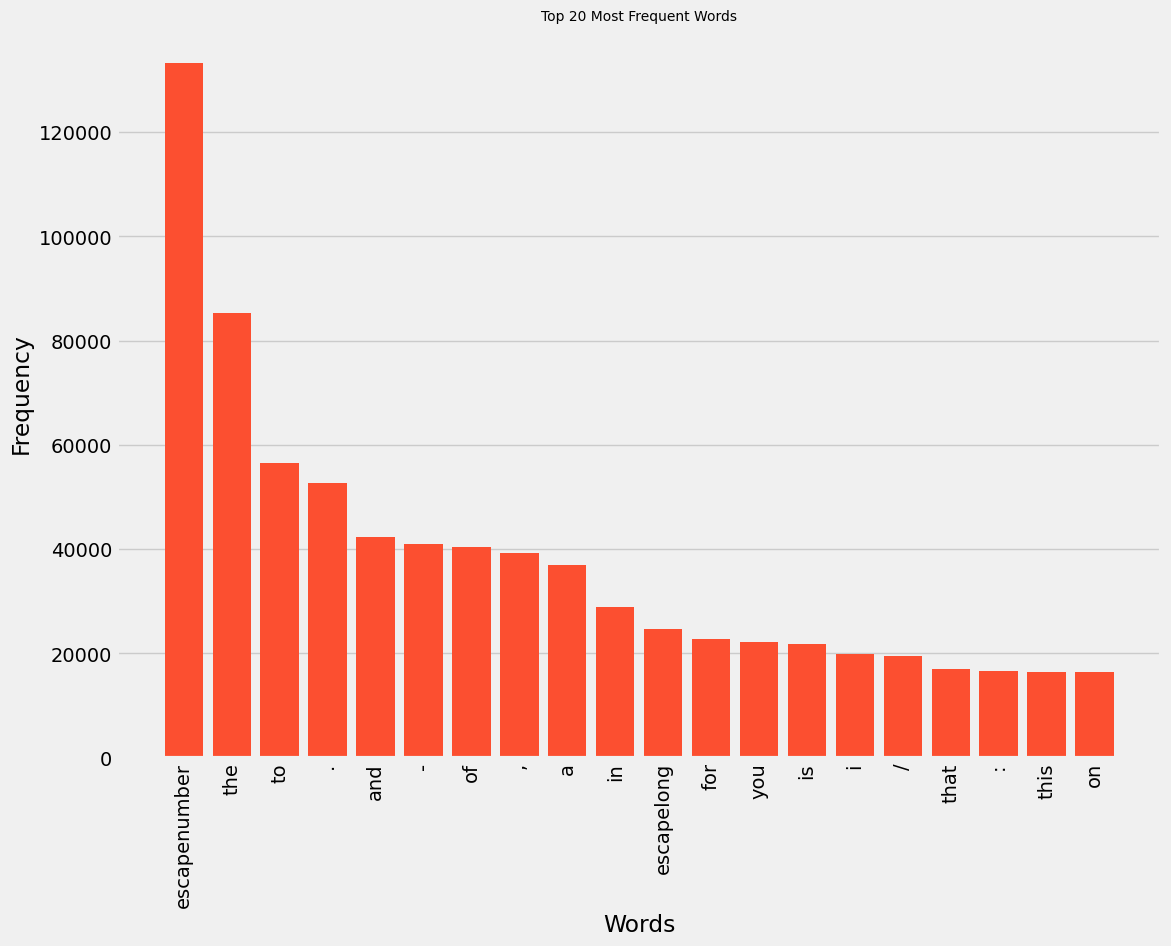

In [22]:
from collections import Counter

all_words = ' '.join(df['text']).lower().split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.rcParams['figure.figsize'] = (12,9)
plt.style.use('fivethirtyeight')
sns.barplot(x=words, y=counts, palette='Blues_d')
plt.title("Top 20 Most Frequent Words", fontweight=11, fontsize=10)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.bar(words, counts)
plt.show()

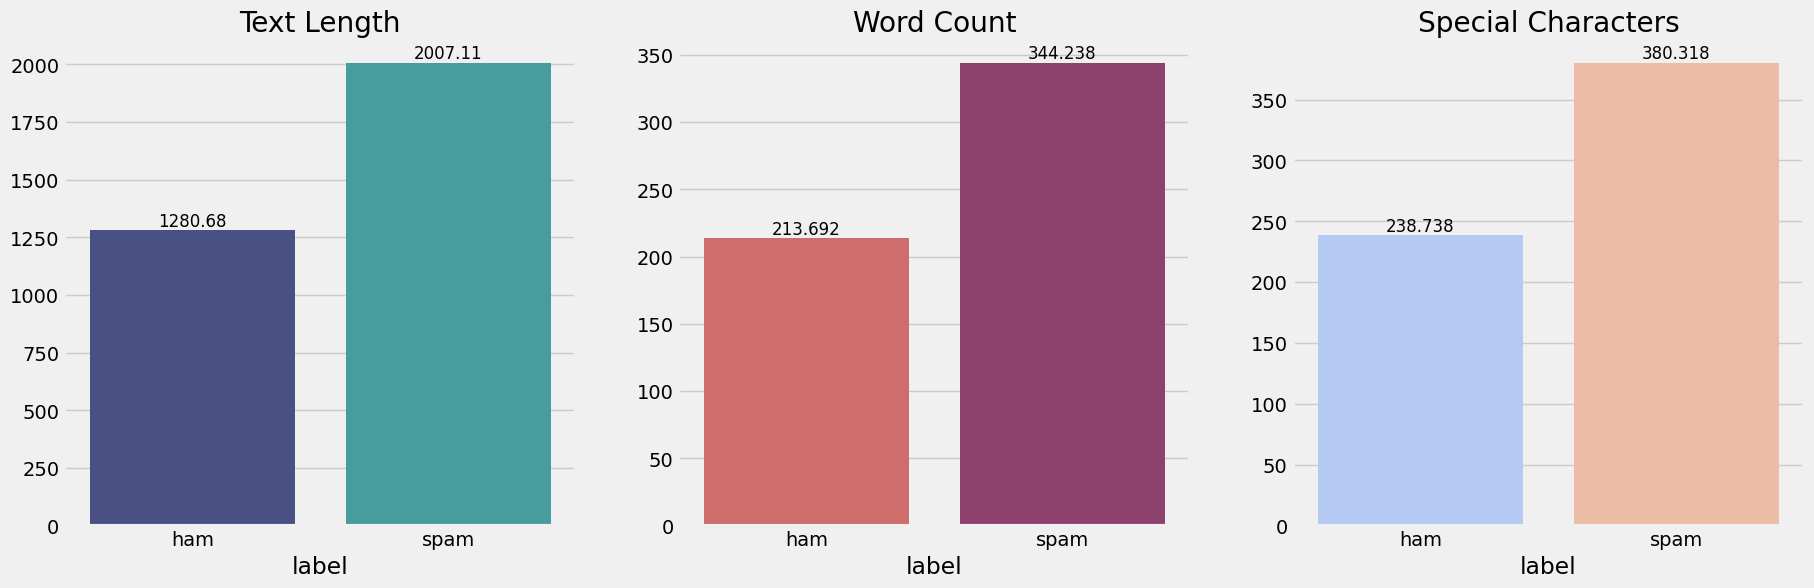

In [23]:
group_data = df.groupby('label')

f, ax = plt.subplots(1,3,figsize=(20,6))

sns.barplot(x=group_data['text_length'].mean().index,
            y=group_data['text_length'].mean().values,
            palette='mako', ax=ax[0])
ax[0].set_title('Text Length')

sns.barplot(x=group_data['word_count'].mean().index,
            y=group_data['word_count'].mean().values,
            palette='flare', ax=ax[1])
ax[1].set_title('Word Count')

sns.barplot(x=group_data['special_char_count'].mean().index,
            y=group_data['special_char_count'].mean().values,
            palette='coolwarm', ax=ax[2])
ax[2].set_title('Special Characters')

for i in range(3):
    for container in ax[i].containers:
        ax[i].bar_label(container, size=12)

plt.show()
plt.close()

### Conclusion
The dataset is balanced and contains diverse text data with minimal duplication
The distributions of text length and word count are right-skewed with some outliers.
Word frequency analysis shows clear differences between spam and ham emails.
Therefore, TF-IDF is an appropriate method for feature extraction

### 6. Data Preprocessing
Data preprocessing is performed to clean and transform raw text data into a suitable format for model training.

In [24]:
df['text'] = df['text'].str.lower()

import string
df['text'] = df['text'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
df['text'] = df['text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in ENGLISH_STOP_WORDS])
)

In [25]:
df['tokens'] = df['text'].apply(lambda x: x.split())
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

##### Split data and TF-IDF

In [26]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

In [28]:
x_train_dense = X_train_tfidf.toarray()
x_test_dense  = X_test_tfidf.toarray()

y_train = y_train.values
y_test  = y_test.values

### 7. Model Training

##### Naive Bayes

vẽ công thức Bayes

$$P(y | x_1, ..., x_n) \propto P(y) \prod_{i=1}^{n} P(x_i | y)$$

Tính prior và likelihood

prior: xác suất của từng class
likelihood: xác suất của từng từ trong class đó (có Laplace smoothing để tránh xác suất = 0)

In [29]:
def fit_naive_bayes(X, y, alpha=1.0):
    classes = np.unique(y)
    n_samples, n_features = X.shape

    log_priors    = {}  # log P(y=k)
    log_likelihoods = {}  # log P(x_i | y=k)

    for c in classes:
        X_c = X[y == c]  # samples thuộc class c

        # prior: log P(y=c)
        log_priors[c] = np.log(X_c.shape[0] / n_samples)

        # likelihood với Laplace smoothing
        word_counts = X_c.sum(axis=0) + alpha          # tổng TF-IDF mỗi từ trong class c
        total       = word_counts.sum()                 # tổng tất cả từ
        log_likelihoods[c] = np.log(word_counts / total)  # log P(x_i | y=c)

    return log_priors, log_likelihoods, classes

Predict

tính log posterior cho từng class rồi chọn class có score cao nhất
$$\hat{y} = \arg\max_k \left[ \log P(y=k) + \sum_{i} x_i \cdot \log P(x_i | y=k) \right]$$

In [30]:
def predict_naive_bayes(X, log_priors, log_likelihoods, classes):
    preds = []
    for x in X:
        scores = {}
        for c in classes:
            # log posterior = log prior + sum(x_i * log likelihood_i)
            scores[c] = log_priors[c] + np.dot(x, log_likelihoods[c])
        preds.append(max(scores, key=scores.get))  # class có score cao nhất
    return np.array(preds)

Train model

In [31]:
log_priors, log_likelihoods, classes = fit_naive_bayes(x_train_dense, y_train, alpha=1.0)
y_test_pred = predict_naive_bayes(x_test_dense, log_priors, log_likelihoods, classes)
print("Training complete!")

Training complete!


Naive Bayes - Loss curve (Log-likelihood per alpha)

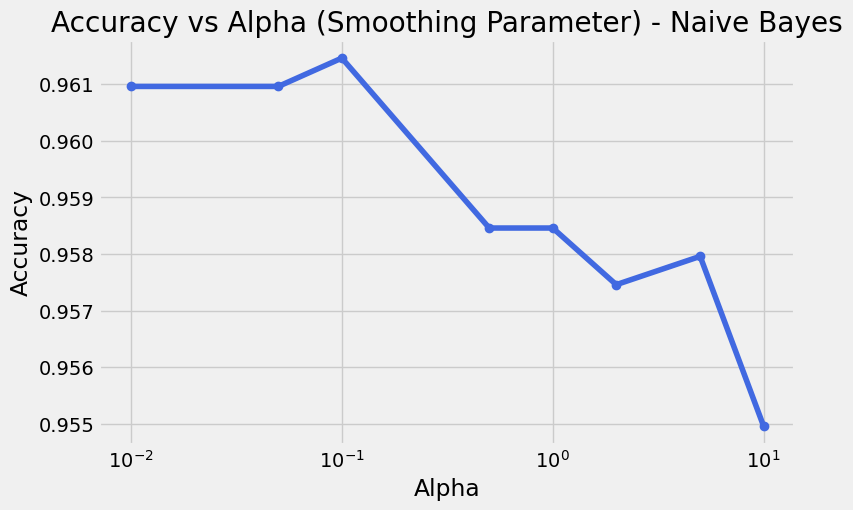

Best alpha : 0.1
Best accuracy: 0.9615


In [32]:
from sklearn.metrics import accuracy_score

alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
acc_scores = []

for a in alphas:
    lp, ll, cls = fit_naive_bayes(x_train_dense, y_train, alpha=a)
    preds = predict_naive_bayes(x_test_dense, lp, ll, cls)
    acc_scores.append(accuracy_score(y_test, preds))

plt.figure(figsize=(8,5))
plt.plot(alphas, acc_scores, marker='o', color='royalblue')
plt.xscale('log')
plt.title("Accuracy vs Alpha (Smoothing Parameter) - Naive Bayes")
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.grid(True)
plt.savefig("alpha_vs_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

best_alpha = alphas[np.argmax(acc_scores)]
print(f"Best alpha : {best_alpha}")
print(f"Best accuracy: {max(acc_scores):.4f}")

In [33]:
# Retrain with best alpha
log_priors, log_likelihoods, classes = fit_naive_bayes(x_train_dense, y_train, alpha=best_alpha)
y_test_pred = predict_naive_bayes(x_test_dense, log_priors, log_likelihoods, classes)

              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1058
           1       0.95      0.97      0.96       940

    accuracy                           0.96      1998
   macro avg       0.96      0.96      0.96      1998
weighted avg       0.96      0.96      0.96      1998

[[1005   53]
 [  24  916]]


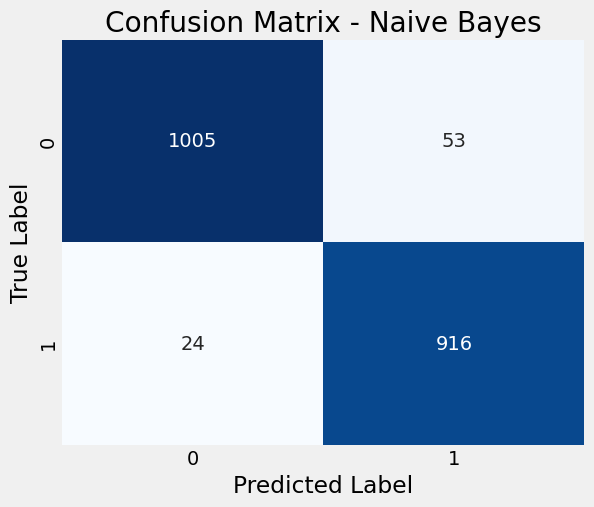

In [34]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()